# Insurance Data Cleaning, EDA, and Model Pipeline

This notebook loads the insurance dataset from `../data/insurance.csv`, performs basic cleaning and exploratory data analysis, and then trains a KNN regression model. The fitted scaler and model are saved into the `../models/` folder.

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

sns.set(style="darkgrid")

## Load data

In [22]:
data_path = os.path.join('..', 'data', 'insurance.csv')
df = pd.read_csv(data_path)
df.columns = df.columns.str.lower()
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data overview

In [23]:
print('Shape:', df.shape)
print('Missing values:')
print(df.isna().sum())

display(df.describe(include='all'))

Shape: (1338, 7)
Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


## Data cleaning

In [24]:
# Check duplicates
duplicates = df.duplicated().sum()
print('Duplicate rows:', duplicates)

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print('Dropped duplicate rows')

# Convert categorical text to consistent lowercase strings
for col in ['sex', 'smoker', 'region']:
    df[col] = df[col].astype(str).str.lower().str.strip()

# Verify cleaned data
print(df[['sex','smoker','region']].nunique())
df.head()

Duplicate rows: 1
Dropped duplicate rows
sex       2
smoker    2
region    4
dtype: int64


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Feature engineering and encoding

In [25]:
df_processed = df.copy()
label_encoders = {}
for col in ['sex', 'smoker', 'region']:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le

display(df_processed.head())

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


## Exploratory Data Analysis

C:\Users\harsh\AppData\Local\Temp\ipykernel_29740\1990618874.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='children', ax=axes[1,0], palette='muted')
C:\Users\harsh\AppData\Local\Temp\ipykernel_29740\1990618874.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='smoker', ax=axes[1,1], palette='flare')


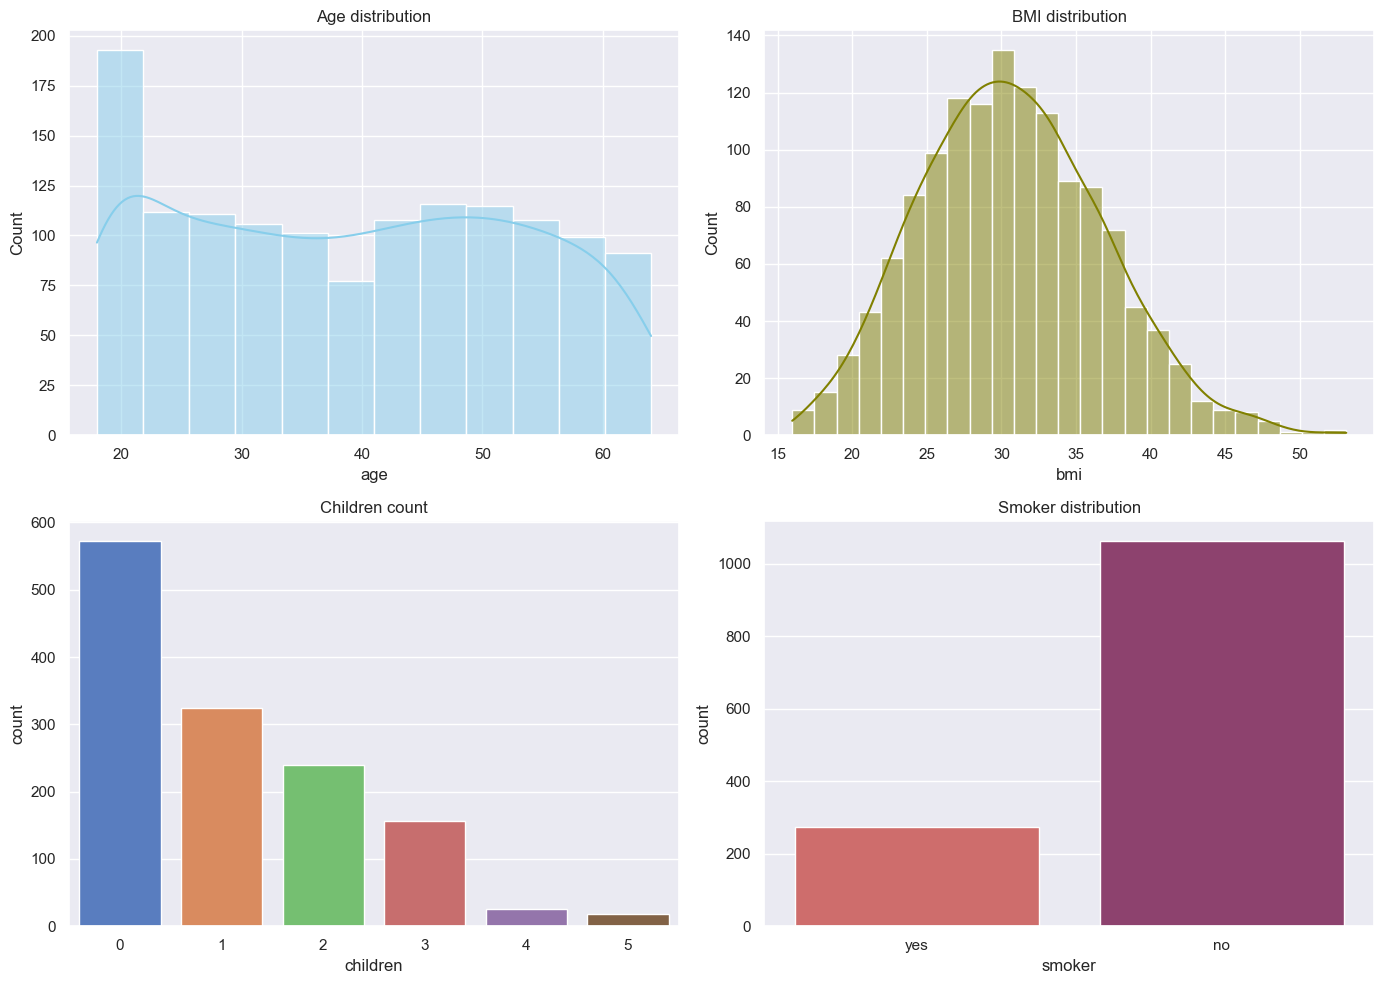

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['age'], kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Age distribution')
sns.histplot(df['bmi'], kde=True, ax=axes[0,1], color='olive')
axes[0,1].set_title('BMI distribution')
sns.countplot(data=df, x='children', ax=axes[1,0], palette='muted')
axes[1,0].set_title('Children count')
sns.countplot(data=df, x='smoker', ax=axes[1,1], palette='flare')
axes[1,1].set_title('Smoker distribution')
plt.tight_layout()
plt.show()

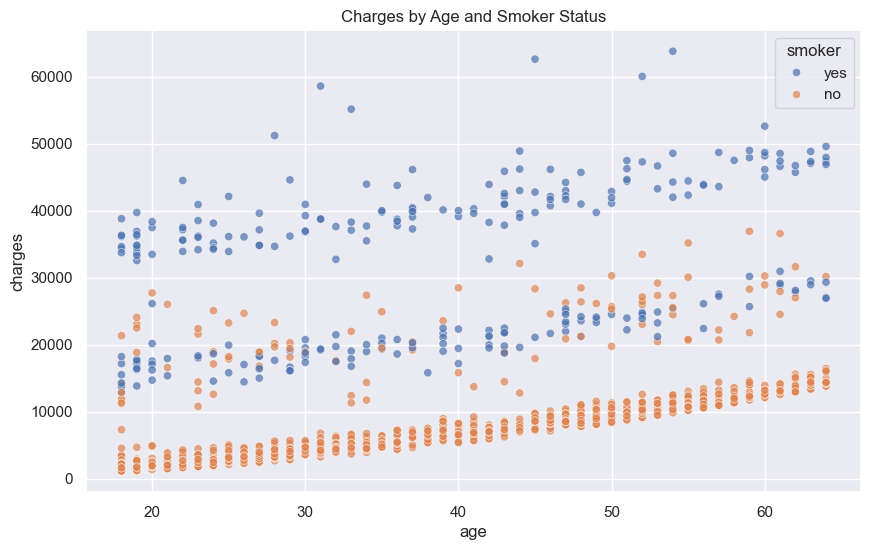

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.7)
plt.title('Charges by Age and Smoker Status')
plt.show()

## Train/test split, scaling, and model training

In [28]:
X = df_processed.drop(columns=['charges'])
y = df_processed['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

knn = KNeighborsRegressor()
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print('Best hyperparameters:', grid_search.best_params_)

best_pred = best_model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, best_pred)
rmse = np.sqrt(mean_squared_error(y_test, best_pred))
r2 = r2_score(y_test, best_pred)

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R^2: {r2:.3f}')

model = best_model

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best hyperparameters: {'n_neighbors': 11, 'p': 2, 'weights': 'distance'}
MAE: 3144.59
RMSE: 5157.87
R^2: 0.855


## Save scaler and model to `models/`

In [29]:
model_dir = os.path.join('..', 'models')
os.makedirs(model_dir, exist_ok=True)
joblib.dump(scaler, os.path.join(model_dir, 'scaler.pkl'))
joblib.dump(model, os.path.join(model_dir, 'knn_regressor.pkl'))
joblib.dump(label_encoders, os.path.join(model_dir, 'label_encoders.pkl'))
print('Saved scaler, model, and encoders to models folder')

Saved scaler, model, and encoders to models folder


## Load and verify saved objects

In [30]:
loaded_scaler = joblib.load(os.path.join(model_dir, 'scaler.pkl'))
loaded_model = joblib.load(os.path.join(model_dir, 'knn_regressor.pkl'))
loaded_encoders = joblib.load(os.path.join(model_dir, 'label_encoders.pkl'))
sample_input = X_test.iloc[:3].copy()
sample_scaled = loaded_scaler.transform(sample_input)
print('Sample predictions:', loaded_model.predict(sample_scaled))

Sample predictions: [ 9875.72432991  7715.96880699 13995.30002103]
